<a href="https://colab.research.google.com/github/zilbersm/ZilbersteinM_Neur265/blob/main/homework/coding_homework_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Maya Zilberstein

*Introduction to Neural Data Analysis (Neur 265)*

**04/10/2026**


In [95]:
#Imports python libraries

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

In [112]:
#Imports relavent data files as numpy arrays

fear_traces = np.loadtxt('https://raw.githubusercontent.com/hallockh/neur_265_spring2026/refs/heads/main/data/fear_conditioning_traces_hw8.csv', delimiter=',')
extinction_predictors = np.loadtxt('https://raw.githubusercontent.com/hallockh/neur_265_spring2026/refs/heads/main/data/extinction_predictors_hw8.csv', delimiter=',')
shock_index = np.loadtxt('https://raw.githubusercontent.com/hallockh/neur_265_spring2026/refs/heads/main/data/shock_index.csv', delimiter=',').astype(int)
tone_index = np.loadtxt('https://raw.githubusercontent.com/hallockh/neur_265_spring2026/refs/heads/main/data/tone_index.csv', delimiter=',').astype(int)



In [97]:
#Splits the fear_traces into two arrays, one for conditioning and one for extinction

conditioning_traces = fear_traces[0:10458]
extinction_traces = fear_traces[10458: ] #instructions say items 10459 and up... however, we are also told that conditioning_traces should have the first 10458 items which means 0 to 10457...

In [98]:
#prints the sizes of the two arrays created in the previous cell
print(f'Conditioning traces size: {conditioning_traces.size}')
print(f'Extinction traces size: {extinction_traces.size}')

#Also wanted to print the shapes
print(f'Conditioning traces shape: {conditioning_traces.shape}')
print(f'Extinction traces shape: {extinction_traces.shape}')

Conditioning traces size: 658854
Extinction traces size: 895230
Conditioning traces shape: (10458, 63)
Extinction traces shape: (14210, 63)


In [99]:
#Creates time variables for the two arrays conditioning_traces and extinction_traces

time_conditioning = np.linspace(0, conditioning_traces.shape[0]/15, conditioning_traces.shape[0])
time_extinction = np.linspace(0, extinction_traces.shape[0]/15, extinction_traces.shape[0])

**Number of ROIs:** 63

**Conditioning Length:** 697.2 seconds (~11.62 minutes)

**Extinction Length:** 947.33 seconds (~15.79 minutes)

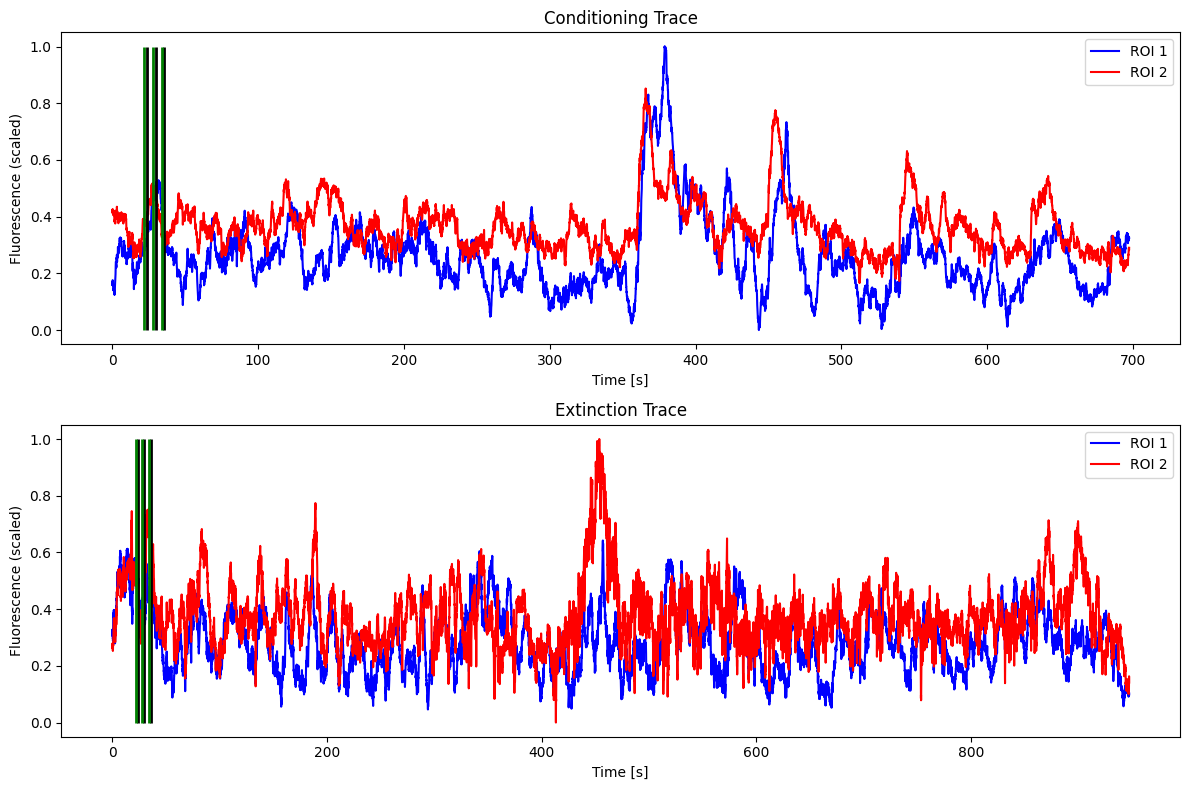

In [100]:
#Sets up the subplots
fig, ax = plt.subplots(2, 1, figsize=(12, 8))

#Plots first two ROIs (one in blue and one in red) of the conditioning data
ax[0].plot(time_conditioning, conditioning_traces[:,0], color='blue', label='ROI 1')
ax[0].plot(time_conditioning, conditioning_traces[:,1], color='red', label='ROI 2')

#Plots the vertical lines in black and green according to the shock_index and tone_index respectively
ax[0].vlines(time_conditioning[shock_index], 0, 1, 'k', lw=2, color= 'black')
ax[0].vlines(time_conditioning[tone_index], 0, 1, 'k', lw=2, color= 'green')

#Labels axes, adds title and legend
ax[0].set_xlabel('Time [s]')
ax[0].set_ylabel('Fluorescence (scaled)')
ax[0].set_title('Conditioning Trace')
ax[0].legend()

#Plots first two ROIs (one in blue and one in red) of the extinction data
ax[1].plot(time_extinction, extinction_traces[:,0], color='blue', label='ROI 1')
ax[1].plot(time_extinction, extinction_traces[:,1], color='red', label='ROI 2')

#Plots the vertical lines in black and green according to the shock_index and tone_index respectively
ax[1].vlines(time_conditioning[shock_index], 0, 1, 'k', lw=2, color= 'black')
ax[1].vlines(time_conditioning[tone_index], 0, 1, 'k', lw=2, color= 'green')

#Labels axes, adds title and legend
ax[1].set_xlabel('Time [s]')
ax[1].set_ylabel('Fluorescence (scaled)')
ax[1].set_title('Extinction Trace')
ax[1].legend()

#Acually plots the graph
plt.tight_layout()
plt.show()

For both the conditioning and extinction data, it looks like the second ROI generally has slightly higher value of scaled flourescence than the first ROI.

For the conditioning data, the power of the two graphs is relatively slimilar. However, there are noteworthy peaks past the 350 seconds mark that increase the variability.

For the extinction data, although it looks like the first ROI has more waves in the data, it does look like the second ROI has more power.

When comparing the conditioning and exctinction data as wholes, we may notice that the extinction data has more power and might even have slightly higher fluoresence values than the conditioning data most of the time. I believe that this means that cells respond a bit more strongly during extinction(?).

In [101]:

#Imports pandas (it is used in the 04/02/2026 notebook to make the predictors variable)
from pandas import DataFrame as df

#making shock_array and tone_array variables in the same way as was done in the 04/02/2026 notebook
shock_array = np.zeros(10458)
for i in range(10458):
  if i >= (shock_index[0]-15)*15 and i <= (shock_index[0]+30)*15:
    shock_array[i] = 1
  elif i>= (shock_index[1]-15)*15 and i <= (shock_index[1]+30)*15:
    shock_array[i] = 1
  elif i>= (shock_index[2]-15)*15 and i <= (shock_index[2]+30)*15:
    shock_array[i] = 1
  else:
    shock_array[i] = 0

tone_array = np.zeros(10458)
for i in range(10458):
  if i >= (tone_index[0]-15)*15 and i <= (tone_index[0]+30)*15:
    tone_array[i] = 1
  elif i>= (tone_index[1]-15)*15 and i <= (tone_index[1]+30)*15:
    tone_array[i] = 1
  elif i>= (tone_index[2]-15)*15 and i <= (tone_index[2]+30)*15:
    tone_array[i] = 1
  else:
    tone_array[i] = 0

#Makes the predictors variable by combining the model1 and model3 predictors from the 04/02/2026 notebook
predictors_conditioning = df(data={'Intercept': np.ones_like(tone_array),
                                   'tone onset': tone_array,
                                   'shock onset': shock_array})

/tmp/ipykernel_25155/1303957520.py:20: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


Text(0, 0.5, 'Cumulative Proportion of ROIs')

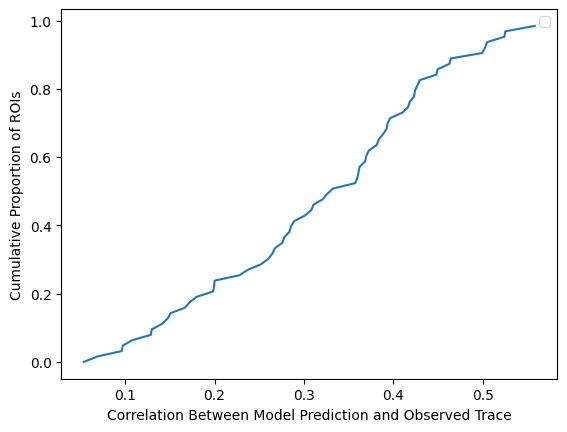

In [102]:
#Imports required libraries for this cell and the next (same as in notebook 04/02/2026)
import statsmodels.api as sm
from statsmodels.genmod.families import Poisson

#Creates the r_model variable for the conditioning data using np.zeros, same as in 04/02/2026
r_index_conditioning = np.zeros(conditioning_traces.shape[1]) #Instructions say to name it r_model_conditioning but then refers to it as r_index_conditioning. I labeled it r_index_conditioning to maintain consistency with the next code cell.

#Modified for loop from 04/02/2026 notebook that correlates the predicted trace vs. actual trace
for i in range(conditioning_traces.shape[1]):
  roi_trace = conditioning_traces[:,i]
  model_cond = sm.GLM(roi_trace, predictors_conditioning, family=Poisson())
  model_cond_results = model_cond.fit()
  predicted_trace_cond = model_cond_results.predict()
  r_cond = pearsonr(roi_trace, predicted_trace_cond)
  r = pearsonr(roi_trace, predicted_trace_cond)
  r_index_conditioning[i] = r_cond.statistic

#Plots the graph
plt.plot(np.sort(r_index_conditioning), np.linspace(0, 1, len(r_index_conditioning), endpoint=False))
plt.xlabel('Correlation Between Model Prediction and Observed Trace')
plt.ylabel('Cumulative Proportion of ROIs')


Text(0, 0.5, 'Cumulative Proportion of ROIs')

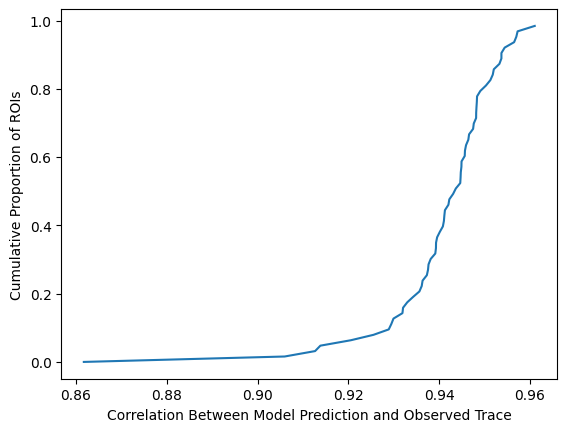

In [116]:
#Creats the extinction_predictors variable
extinction_predictors = df(data={'intercept': np.ones_like(tone_array), 'tone onset': tone_array})

#Creates the r_model variable for the extinction data using np.zeros, same as in 04/02/2026
r_index_extinction = np.zeros(extinction_traces.shape[1])

#Modified for loop from 04/02/2026 notebook that correlates the predicted trace vs. actual trace
for i in range(extinction_traces.shape[1]):
  roi_trace = extinction_traces[:, i]
  model_ex = sm.GLM(roi_trace, extinction_traces, family=Poisson())
  model_ex_results = model_ex.fit()
  predicted_trace_ex = model_ex_results.predict()
  r = pearsonr(roi_trace, predicted_trace_ex)
  r_index_extinction[i] = r.statistic

#Plots the graph
plt.plot(np.sort(r_index_extinction), np.linspace(0, 1, len(r_index_extinction), endpoint=False))
plt.xlabel('Correlation Between Model Prediction and Observed Trace')
plt.ylabel('Cumulative Proportion of ROIs')

In [119]:
#Conducts the pearson correlation
r, p = pearsonr(r_index_conditioning, r_index_extinction)
print(r, p)

0.20931585665582547 0.09967775344396429


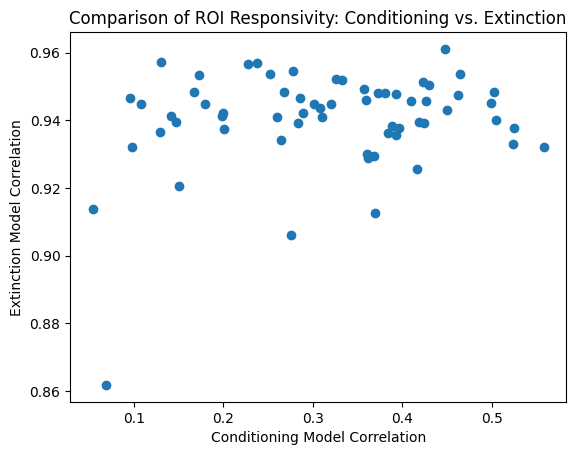

In [118]:
# Plot conditioning r-values on x and extinction r-values on y
plt.scatter(r_index_conditioning, r_index_extinction) #, alpha=0.6

# Label the axes as required by the instructions [cite: 69]
plt.xlabel('Conditioning Model Correlation')
plt.ylabel('Extinction Model Correlation')
plt.title('Comparison of ROI Responsivity: Conditioning vs. Extinction')

#Plots the graph
plt.show()

Considering both the scatter plot and the r value from the corelation correlation (0.21), there seems to be a (very) slightly positive though somewhat weak relationship between how a cell respondes during conditioning and how it responds during extinction. However, it seem like the cell generally responds more strongly during the extinction process than the conditioning process judging by the axis values.

Overall, if I am understanding the graph correctly, it does not really seem like a cell that responds strongly to shock and tone onset during the conditioning session is more likely to respond stongly to tone onset during the extinction process. Regardless of the slightly positive correlation, the scatter plot shows high values for nearly all the extinction model correlation values and varied values for the conditioning model correlation.